# Model Evaluation

This notebook demonstrates standardized evaluation of trained machine learning
models for the Network Threat Cognition Framework (NTCF).

The notebook performs the following tasks:

- Load a trained model
- Load the processed dataset
- Generate predictions
- Calculate evaluation metrics
- Generate a classification report
- Display a confusion matrix
- Demonstrate that the evaluation utilities are reusable for different models

In [28]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project Root:", project_root)

Project Root: c:\Users\dell\Documents\NTCF-minor-project-


In [29]:
from pathlib import Path

from ml.models import (
    decision_tree_model,
    random_forest_model,
    svm_model,
)

from ml.evaluation.metrics import (
    calculate_all_metrics,
)

from ml.evaluation.confusion_matrix import (
    plot_confusion_matrix,
)

from ml.evaluation.evaluation_report import (
    generate_classification_report,
)

In [30]:
from pathlib import Path

def load_project_model(model_name):
    """
    Load a trained model regardless of the API used by
    the individual model implementation.
    """

    project_root = Path.cwd().parent
    artifact_dir = project_root / "ml" / "artifacts"

    if model_name == "Decision Tree":
        return decision_tree_model.load_model()

    elif model_name == "Random Forest":
        return random_forest_model.RandomForestModel.load(
            artifact_dir / "random_forest_model.pkl"
        )

    elif model_name == "SVM":
        return svm_model.load_model()

    else:
        raise ValueError(f"Unsupported model: {model_name}")

In [31]:
X_train, X_test, y_train, y_test = (
    decision_tree_model.load_processed_data()
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("Number of Features :", X_train.shape[1])

Training Samples : 100778
Testing Samples  : 25195
Number of Features : 122


In [32]:
# Select one model

# MODEL_NAME = "Decision Tree"

MODEL_NAME = "Random Forest"

#MODEL_NAME = "SVM"

model = load_project_model(MODEL_NAME)

print(f"{MODEL_NAME} loaded successfully.")

Random Forest loaded successfully.


In [33]:
predictions = model.predict(X_test)

print("First 10 Predictions:")
print(predictions[:10])

First 10 Predictions:
['normal' 'neptune' 'neptune' 'neptune' 'portsweep' 'normal' 'neptune'
 'neptune' 'neptune' 'normal']


In [34]:
metrics = calculate_all_metrics(
    y_test,
    predictions,
)

print("Evaluation Metrics\n")

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Evaluation Metrics

Accuracy: 0.9914
Precision: 0.9943
Recall: 0.9914
F1-Score: 0.9923


In [35]:
report = generate_classification_report(
    y_test,
    predictions,
)

print(report)

                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       185
buffer_overflow       1.00      0.33      0.50         9
      ftp_write       0.00      0.00      0.00         0
   guess_passwd       1.00      0.91      0.95        11
           imap       0.25      1.00      0.40         1
        ipsweep       0.98      1.00      0.99       733
           land       0.60      1.00      0.75         3
     loadmodule       0.00      0.00      0.00         0
       multihop       0.00      0.00      0.00         0
        neptune       1.00      1.00      1.00      8228
           nmap       0.96      0.99      0.97       313
         normal       1.00      0.99      0.99     13422
           perl       1.00      1.00      1.00         1
            phf       1.00      1.00      1.00         1
            pod       1.00      0.93      0.96        43
      portsweep       0.99      1.00      1.00       573
        rootkit       0.00    

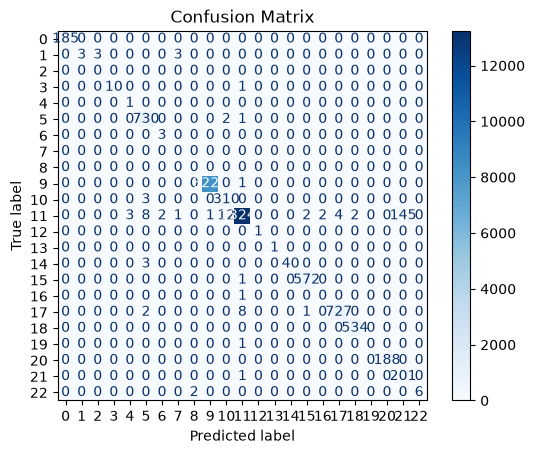

In [36]:
plot_confusion_matrix(
    y_test,
    predictions,
)

# Conclusion

The standardized evaluation utilities successfully evaluated the selected
machine learning model using the processed NSL-KDD dataset.

The evaluation workflow included:

- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report
- Confusion Matrix

These utilities are model-independent and can be reused without modification
for:

- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

This notebook satisfies the requirements of **Issue #16 – Model Evaluation**.